# 使用 MMDetection 进行人脸检测

本 Notebook 对应任务 2.3：使用 MMDetection 的 Grounding DINO 模型，在测试图像中检测人脸，并使用 OpenCV 绘制边界框和置信度。

## 实验目标

- 验证 PyTorch、MMCV、MMEngine 和 MMDetection 环境；
- 使用 NVIDIA GPU 完成人脸检测推理；
- 读取并展示测试图像；
- 使用 `face` 文本提示检测人脸；
- 使用 OpenCV 绘制检测框并保存结果；
- 分析检测数量、置信度和阈值的影响。

## 1. 运行环境

推荐在 Windows + NVIDIA GPU 的独立 Conda 环境中运行：

```text
Python       3.10
PyTorch      2.1.0 + CUDA 12.1
MMCV         2.1.0
MMEngine     0.10.7
MMDetection  3.3.0
```

Grounding DINO 是开放词汇目标检测模型，可以通过文本提示指定需要检测的类别。本实验使用 `face .` 作为提示词。它适合展示 MMDetection 推理流程，但不是专门在 WIDER FACE 上训练的人脸检测器。

In [1]:
from pathlib import Path
from time import perf_counter

import cv2
import matplotlib.pyplot as plt
import mmcv
import mmengine
import mmdet
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from mmcv.ops import nms  # 验证 MMCV 完整算子可用
from mmdet.apis import DetInferencer

print("PyTorch:", torch.__version__)
print("CUDA runtime:", torch.version.cuda)
print("MMCV:", mmcv.__version__)
print("MMEngine:", mmengine.__version__)
print("MMDetection:", mmdet.__version__)
print("OpenCV:", cv2.__version__)
print("CUDA 可用:", torch.cuda.is_available())

assert torch.cuda.is_available(), "未检测到 NVIDIA GPU，请检查驱动和 CUDA 版 PyTorch"

DEVICE = "cuda:0"
print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.1.0+cu118
CUDA runtime: 11.8
MMCV: 2.1.0
MMEngine: 0.10.7
MMDetection: 3.3.0
OpenCV: 4.10.0
CUDA 可用: True
GPU: NVIDIA GeForce RTX 3080


## 2. 准备测试图像

将一张包含单人或多人的 JPG/PNG 图片放入：

```text
face_recognition/test_images/
```

下面的代码会自动选择目录中的第一张图片。如果目录为空，但本地存在 LFW 数据集，则使用第一张 LFW 图片。

In [9]:
WORKING_DIR = Path.cwd().resolve()
PROJECT_ROOT = WORKING_DIR.parent if WORKING_DIR.name == "face_recognition" else WORKING_DIR

TEST_IMAGE_DIR = PROJECT_ROOT / "face_recognition" / "test_images"
OUTPUT_DIR = PROJECT_ROOT / "face_recognition" / "outputs" / "face_detection"
TEST_IMAGE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

supported_extensions = {".jpg", ".jpeg", ".png", ".bmp"}
image_paths = sorted(
    path for path in TEST_IMAGE_DIR.iterdir()
    if path.is_file() and path.suffix.lower() in supported_extensions
)

if not image_paths:
    lfw_dir = PROJECT_ROOT / "data" / "lfw" / "lfw-deepfunneled"
    image_paths = sorted(lfw_dir.glob("*/*.jpg")) if lfw_dir.exists() else []

assert image_paths, f"请先把测试图片放入：{TEST_IMAGE_DIR}"

MAX_IMAGES = 3
IMAGE_PATHS = image_paths[:MAX_IMAGES]

print(f"本次测试 {len(IMAGE_PATHS)} 张图片：")
for image_path in IMAGE_PATHS:
    print("-", image_path)

本次测试 3 张图片：
- D:\InternProject\face-vision-lab\data\lfw\lfw-deepfunneled\Aaron_Eckhart\Aaron_Eckhart_0001.jpg
- D:\InternProject\face-vision-lab\data\lfw\lfw-deepfunneled\Aaron_Guiel\Aaron_Guiel_0001.jpg
- D:\InternProject\face-vision-lab\data\lfw\lfw-deepfunneled\Aaron_Patterson\Aaron_Patterson_0001.jpg


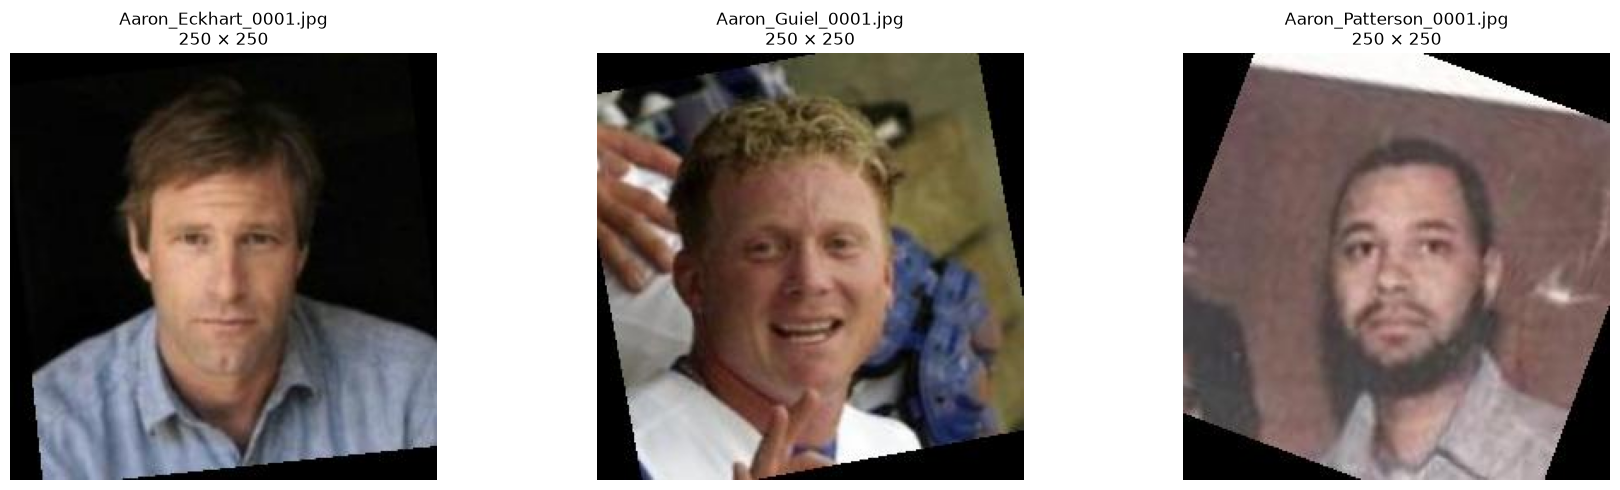

In [10]:
fig, axes = plt.subplots(1, len(IMAGE_PATHS), figsize=(6 * len(IMAGE_PATHS), 5))
axes = np.atleast_1d(axes)

for axis, image_path in zip(axes, IMAGE_PATHS):
    image_bgr = cv2.imread(str(image_path))
    assert image_bgr is not None, f"OpenCV 无法读取图片：{image_path}"
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    axis.imshow(image_rgb)
    axis.set_title(f"{image_path.name}\n{image_bgr.shape[1]} × {image_bgr.shape[0]}")
    axis.axis("off")

plt.tight_layout()
plt.show()

## 3. 初始化 Grounding DINO

MMDetection 模型由配置文件和模型权重共同定义。代码从已安装的 `mmdet` 包中定位配置文件，并从 OpenMMLab 官方地址下载预训练权重。

> 第一次运行会下载 Grounding DINO 权重和 `bert-base-uncased`，需要联网并等待几分钟。之后会使用本地缓存。

In [4]:
CONFIG_PATH = (
    Path(mmdet.__file__).resolve().parent
    / ".mim"
    / "configs"
    / "grounding_dino"
    / "grounding_dino_swin-t_pretrain_obj365_goldg_cap4m.py"
)

WEIGHTS_URL = (
    "https://download.openmmlab.com/mmdetection/v3.0/grounding_dino/"
    "groundingdino_swint_ogc_mmdet-822d7e9d.pth"
)

assert CONFIG_PATH.exists(), (
    f"找不到 Grounding DINO 配置：{CONFIG_PATH}。"
    "请确认安装的是完整的 mmdet==3.3.0。"
)

print("配置文件：", CONFIG_PATH)

inferencer = DetInferencer(
    model=str(CONFIG_PATH),
    weights=WEIGHTS_URL,
    device=DEVICE,
    show_progress=False,
)

print("模型加载完成")

配置文件： D:\InternProject\face-vision-lab\.venv\Lib\site-packages\mmdet\.mim\configs\grounding_dino\grounding_dino_swin-t_pretrain_obj365_goldg_cap4m.py
Loads checkpoint by http backend from path: https://download.openmmlab.com/mmdetection/v3.0/grounding_dino/groundingdino_swint_ogc_mmdet-822d7e9d.pth


Downloading: "https://download.openmmlab.com/mmdetection/v3.0/grounding_dino/groundingdino_swint_ogc_mmdet-822d7e9d.pth" to C:\Users\xjyy/.cache\torch\hub\checkpoints\groundingdino_swint_ogc_mmdet-822d7e9d.pth
d:\InternProject\face-vision-lab\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

The model and loaded state dict do not match exactly

unexpected key in source state_dict: language_model.language_backbone.body.model.embeddings.position_ids

missing keys in source state_dict: dn_query_generator.label_embedding.weight



d:\InternProject\face-vision-lab\.venv\Lib\site-packages\mmdet\apis\det_inferencer.py:130: UserWarning: dataset_meta or class names are not saved in the checkpoint's meta data, use COCO classes by default.
  warnings.warn(


08/06 16:29:12 - mmengine - WARNING - Failed to search registry with scope "mmdet" in the "function" registry tree. As a workaround, the current "function" registry in "mmengine" is used to build instance. This may cause unexpected failure when running the built modules. Please check whether "mmdet" is a correct scope, or whether the registry is initialized.
模型加载完成


d:\InternProject\face-vision-lab\.venv\Lib\site-packages\mmengine\visualization\visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '


## 4. 执行人脸检测

`SCORE_THRESHOLD` 是置信度阈值。阈值较低会保留更多候选框，但可能增加误检；阈值较高会减少误检，但可能漏掉小脸、侧脸或模糊人脸。

In [12]:
TEXT_PROMPT = "face ."
SCORE_THRESHOLD = 0.25

start_time = perf_counter()
result = inferencer(
    inputs=[str(image_path) for image_path in IMAGE_PATHS],
    batch_size=1,
    texts=TEXT_PROMPT,
    custom_entities=True,
    pred_score_thr=SCORE_THRESHOLD,
    return_vis=True,
    no_save_vis=True,
    no_save_pred=True,
)
inference_seconds = perf_counter() - start_time

prediction_items = []

for image_path, prediction in zip(IMAGE_PATHS, result["predictions"]):
    all_scores = np.asarray(prediction["scores"], dtype=float)
    all_bboxes = np.asarray(prediction["bboxes"], dtype=float).reshape(-1, 4)
    assert len(all_scores) == len(all_bboxes)

    keep = all_scores >= SCORE_THRESHOLD
    prediction_items.append({
        "image_path": image_path,
        "all_scores": all_scores,
        "face_scores": all_scores[keep],
        "face_bboxes": all_bboxes[keep],
    })

print(f"总推理时间：{inference_seconds:.3f} 秒")
print(f"平均每张：{inference_seconds / len(IMAGE_PATHS):.3f} 秒")
print(f"置信度阈值：{SCORE_THRESHOLD:.2f}")
for item in prediction_items:
    print(f"{item['image_path'].name}: {len(item['face_bboxes'])} 张人脸")

d:\InternProject\face-vision-lab\.venv\Lib\site-packages\mmcv\cnn\bricks\transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'


总推理时间：0.887 秒
平均每张：0.296 秒
置信度阈值：0.25
Aaron_Eckhart_0001.jpg: 1 张人脸
Aaron_Guiel_0001.jpg: 1 张人脸
Aaron_Patterson_0001.jpg: 1 张人脸


## 5. 使用 OpenCV 绘制并保存结果

检测结果已保存： D:\InternProject\face-vision-lab\face_recognition\outputs\face_detection\Aaron_Eckhart_0001_face_detection.jpg
检测结果已保存： D:\InternProject\face-vision-lab\face_recognition\outputs\face_detection\Aaron_Guiel_0001_face_detection.jpg
检测结果已保存： D:\InternProject\face-vision-lab\face_recognition\outputs\face_detection\Aaron_Patterson_0001_face_detection.jpg


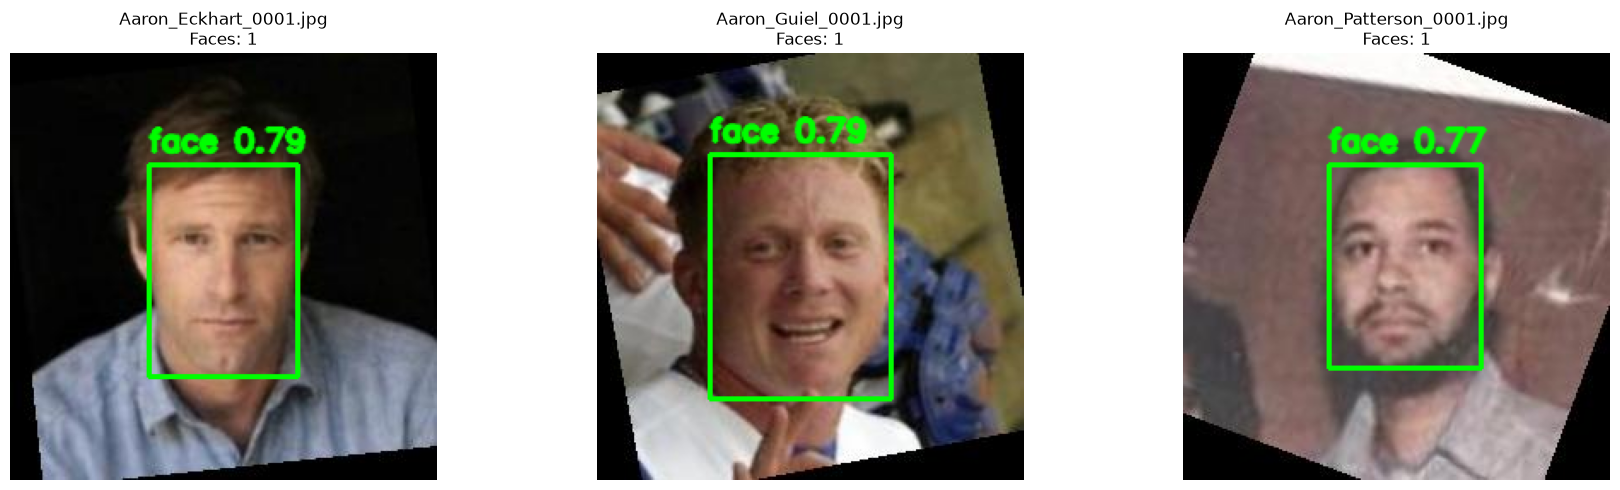

In [13]:
detection_rows = []
fig, axes = plt.subplots(1, len(prediction_items), figsize=(6 * len(prediction_items), 5))
axes = np.atleast_1d(axes)

for axis, item in zip(axes, prediction_items):
    image_path = item["image_path"]
    face_bboxes = item["face_bboxes"]
    face_scores = item["face_scores"]
    annotated_bgr = cv2.imread(str(image_path))
    assert annotated_bgr is not None
    image_height, image_width = annotated_bgr.shape[:2]

    for face_id, (bbox, score) in enumerate(zip(face_bboxes, face_scores), start=1):
        x1, y1, x2, y2 = np.rint(bbox).astype(int)
        x1, x2 = map(int, np.clip([x1, x2], 0, image_width - 1))
        y1, y2 = map(int, np.clip([y1, y2], 0, image_height - 1))

        cv2.rectangle(annotated_bgr, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            annotated_bgr, f"face {score:.2f}",
            (x1, max(y1 - 8, 20)), cv2.FONT_HERSHEY_SIMPLEX,
            0.6, (0, 255, 0), 2, cv2.LINE_AA,
        )

        detection_rows.append({
            "image": image_path.name,
            "face_id": face_id,
            "score": round(float(score), 4),
            "x1": x1, "y1": y1, "x2": x2, "y2": y2,
        })

    result_path = OUTPUT_DIR / f"{image_path.stem}_face_detection.jpg"
    assert cv2.imwrite(str(result_path), annotated_bgr), f"无法保存：{result_path}"
    axis.imshow(cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB))
    axis.set_title(f"{image_path.name}\nFaces: {len(face_bboxes)}")
    axis.axis("off")
    print("检测结果已保存：", result_path)

plt.tight_layout()
plt.show()

## 6. 查看检测数据

In [14]:
detections = pd.DataFrame(
    detection_rows,
    columns=["image", "face_id", "score", "x1", "y1", "x2", "y2"],
)

detections

,image,face_id,score,x1,y1,x2,y2
0,Aaron_Eckhart_0001.jpg,1,0.7861,81,65,168,189
1,Aaron_Guiel_0001.jpg,1,0.7860,66,59,172,202
2,Aaron_Patterson_0001.jpg,1,0.7691,85,65,174,184


## 7. 阈值敏感性分析

下面使用同一次模型输出，比较不同置信度阈值下保留的候选框数量，不会重复执行模型推理。

,image,threshold,detections
0,Aaron_Eckhart_0001.jpg,0.15,1
1,Aaron_Eckhart_0001.jpg,0.25,1
2,Aaron_Eckhart_0001.jpg,0.40,1
3,Aaron_Eckhart_0001.jpg,0.60,1
4,Aaron_Guiel_0001.jpg,0.15,1
5,Aaron_Guiel_0001.jpg,0.25,1
6,Aaron_Guiel_0001.jpg,0.40,1
7,Aaron_Guiel_0001.jpg,0.60,1
8,Aaron_Patterson_0001.jpg,0.15,5
9,Aaron_Patterson_0001.jpg,0.25,1


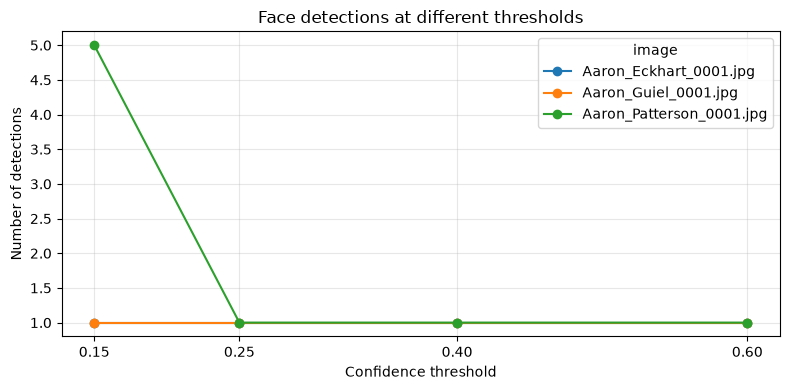

In [15]:
thresholds = np.array([0.15, 0.25, 0.40, 0.60])
threshold_analysis = pd.DataFrame([
    {
        "image": item["image_path"].name,
        "threshold": threshold,
        "detections": int(np.sum(item["all_scores"] >= threshold)),
    }
    for item in prediction_items
    for threshold in thresholds
])
display(threshold_analysis)

threshold_analysis.pivot(
    index="threshold", columns="image", values="detections"
).plot(marker="o", figsize=(8, 4))
plt.xlabel("Confidence threshold")
plt.ylabel("Number of detections")
plt.title("Face detections at different thresholds")
plt.xticks(thresholds)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. 实验结论

本实验完成了以下工作：

1. 验证了 PyTorch、CUDA、MMCV 和 MMDetection 环境；
2. 使用 MMDetection 的 Grounding DINO 预训练模型执行开放词汇人脸检测；
3. 使用 `face .` 文本提示指定检测目标；
4. 使用 OpenCV 绘制人脸边界框和置信度；
5. 保存检测结果并统计边界框坐标；
6. 比较了不同置信度阈值对检测数量的影响。

### 局限性

- Grounding DINO 是通用开放词汇检测器，不是专用人脸检测器；
- 小尺寸、遮挡、侧脸、模糊和极端光照可能导致漏检；
- 降低阈值可能提高召回率，但也可能产生误检；
- 本实验只展示定性结果，没有在 WIDER FACE 等标注数据集上计算 AP。

## 参考资料

1. [MMDetection 3.3.0：使用现有模型推理](https://mmdetection.readthedocs.io/en/v3.3.0/user_guides/inference.html)
2. [MMDetection Grounding DINO](https://github.com/open-mmlab/mmdetection/tree/v3.3.0/configs/grounding_dino)
3. Liu et al., [Grounding DINO: Marrying DINO with Grounded Pre-Training for Open-Set Object Detection](https://arxiv.org/abs/2303.05499)